# Week 7

Finally made the classes done :))

## Phi vals

In [1]:
from src.api.v4 import HMM, GaussEmission, StaticTransition, AutoregressiveGaussEmission
import jax.numpy as jnp 
from src.api.v4.utils import phi_to_phi_tilde 

## VALUES FROM TEXTBOOK EXAMPLE
mean = jnp.array([400, 536, 890, 1307]) 
sd = jnp.array([22, 77, 111, 197])  
u0 = jnp.array([0.19, 0.35, 0.15, 0.32])
Gamma = jnp.array([
            [8.5e-01, 1.5e-01, 0.0028, 9.7e-09],
            [8.3e-02, 8.5e-01, 0.0679, 6.8e-09],
            [4.3e-04, 1.6e-01, 0.6842, 1.5e-01],
            [2.6e-08, 6.1e-09, 0.0723, 9.3e-01],]
            )

gauss_emission = GaussEmission.from_params(mu=mean, sigma=sd)
arr_emission = AutoregressiveGaussEmission.from_params(mu=mean, sigma=sd, phi=jnp.array([0.2, 0.4, 0.8, 0.5]))
transition = StaticTransition.from_params(Gamma)

hmm = HMM(transition=transition, emission=gauss_emission, inital_distribution=u0)
ar_hmm = HMM(transition=transition, emission=arr_emission, inital_distribution=u0) 

In [2]:
from src.api.v4.utils import load_y_data

ys = load_y_data() 

In [3]:
from src.api.v4 import LBFGSSolver


hmm.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False})
ar_hmm.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False})


In [4]:
print(f"Phi vals for AR HMM: {ar_hmm.emission.phi()}")
print(f"Phi tilde is: {ar_hmm.emission.phi_tilde}")

Phi vals for AR HMM: [[0.2580024  0.44656682 0.8969114  0.7361872 ]]
Phi tilde is: [[0.5279343  0.96080744 2.9123945  1.8842069 ]]


### We now build a log likehood plot

In [5]:
ar_hmm = HMM(transition=transition, emission=arr_emission, inital_distribution=u0) 

START_PHI = -0.8
END_PHI = 0.8
idx = (0,)


phi_tilde_param = jnp.linspace(phi_to_phi_tilde(jnp.asarray(START_PHI)), phi_to_phi_tilde(jnp.asarray(END_PHI)), num=30)
phi_tilde_param


Array([-2.1972246 , -2.045692  , -1.8941592 , -1.7426264 , -1.5910937 ,
       -1.439561  , -1.2880282 , -1.1364955 , -0.9849628 , -0.8334302 ,
       -0.68189734, -0.53036463, -0.37883198, -0.22729918, -0.0757665 ,
        0.07576618,  0.22729892,  0.37883165,  0.53036433,  0.68189704,
        0.8334298 ,  0.98496246,  1.1364952 ,  1.288028  ,  1.4395607 ,
        1.5910933 ,  1.7426262 ,  1.8941588 ,  2.0456915 ,  2.1972244 ],      dtype=float32)

In [8]:
ar_hmm.emission.phi_tilde[0]

Array([0.4054652 , 0.84729785, 2.1972244 , 1.0986123 ], dtype=float32)

In [9]:
for phi in phi_tilde_param:
    arr_emission.update_param("phi_tilde", phi, index=idx) 
    ar_hmm.fit(ys=ys, solver=LBFGSSolver(), frozen={"phi_tilde": {0: False}})
    assert ar_hmm.emission.phi_tilde[0, 0] == phi, f"Phi tilde parameter should be updated to {phi} but got {ar_hmm.emission.phi_tilde[0, 0]}"

AssertionError: Phi tilde parameter should be updated to -2.1972246170043945 but got 0.5107765197753906

Text(0.5, 1.0, 'Log-likelihood as a function of phi tilde')

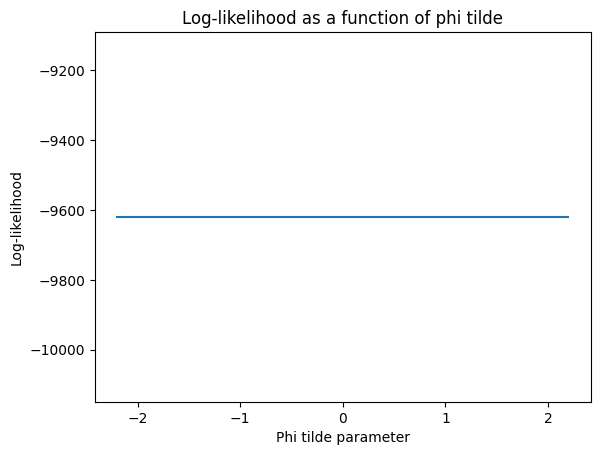

In [ ]:
import matplotlib.pyplot as plt

fit_hist = ar_hmm.ll_fits 
plt.plot(phi_tilde_param, fit_hist)
plt.xlabel("Phi tilde parameter")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood as a function of phi tilde")
plt.show()

In [12]:
fit_hist

[-9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375,
 -9619.990234375]